## Повтор формул с лекции

- Нейрон: $z = w \cdot x + b$
- Гладкая активация: $\hat{y} = \sigma(z) = \dfrac{1}{1+e^{-z}}$
- Функция потерь $L(w)$ — насколько сильно модель ошибается
- Градиент — вектор частных производных: $\nabla L = (\partial L/\partial w_1, ..., \partial L/\partial w_n)$
- Шаг градиентного спуска: $w \leftarrow w - \eta \nabla L$

Сегодня PyTorch возьмёт на себя вычисление $\nabla L$ (это и называется autograd), а сам цикл обновления весов мы напишем своими руками.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
print("PyTorch версия:", torch.__version__)

PyTorch версия: 2.11.0+cpu


---

## Часть 1. PyTorch: тензоры и autograd

Тензор — это, по сути, тот же массив numpy, но с суперспособностью: если сказать `requires_grad=True`, PyTorch запоминает каждую операцию над тензором и потом может сам посчитать производную.

Проверим на игрушечном примере: $y = x^2$. Мы точно знаем аналитически, что $dy/dx = 2x$. Посмотрим, посчитает ли PyTorch то же самое сам.

In [17]:
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2

y.backward()  # здесь PyTorch вычисляет производную

print("x =", x.item())
print("y = x^2 =", y.item())
print("dy/dx, посчитанное PyTorch (x.grad):", x.grad.item())
print("dy/dx по формуле 2x:", 2 * x.item())

x = 3.0
y = x^2 = 9.0
dy/dx, посчитанное PyTorch (x.grad): 6.0
dy/dx по формуле 2x: 6.0


Совпало. Это и есть autograd: `y.backward()` проходит по всем операциям в обратном порядке (отсюда и «обратное распространение», с которым мы подробно встретимся на следующей лекции) и раскладывает производную по всем тензорам с `requires_grad=True`.

> 🎓 **Попробуйте сами:** посчитайте градиент для $y = x^3 + 2x$ в точке $x=2$ и сверьте с формулой $dy/dx = 3x^2+2$.

---

## Часть 2. Градиентный спуск вручную — на одной параболе

Возьмём ту самую функцию потерь с лекции: $L(w) = (w-3)^2 + 1$ — парабола с минимумом в точке $w=3$. Стартуем издалека, например с $w=-2$, и будем спускаться сами, шаг за шагом.

Ниже — каркас цикла с двумя пропущенными строчками. Заполните их по формуле $w \leftarrow w - \eta \cdot \partial L/\partial w$, где `w.grad` — это и есть $\partial L/\partial w$, уже посчитанный PyTorch.

In [4]:
def loss_1d(w):
    return (w - 3.0) ** 2 + 1.0


w = torch.tensor([-2.0], requires_grad=True)
lr = 0.15
history_1d = [(w.item(), loss_1d(w).item())]

for step in range(14):
    loss = loss_1d(w)
    loss.backward()
    with torch.no_grad():
        # ЗАДАНИЕ: обновите w по формуле w <- w - lr * w.grad
        pass  # ВАШ КОД ЗДЕСЬ (1 строка)
    w.grad.zero_()  # обнуляем градиент - иначе PyTorch будет их суммировать
    history_1d.append((w.item(), loss_1d(w).item()))

print("Финальный w:", round(w.item(), 3), " (цель: 3.0)")

Финальный w: -2.0  (цель: 3.0)


### Решение (открыть после самостоятельной попытки)

In [21]:
w = torch.tensor([-2.0], requires_grad=True)
lr = 0.03
history_1d = [(w.item(), loss_1d(w).item())]

for step in range(14):
    loss = loss_1d(w)
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad          # w <- w - eta * dL/dw
    w.grad.zero_()
    history_1d.append((w.item(), loss_1d(w).item()))

print("Финальный w:", round(w.item(), 3), " (цель: 3.0)")
for i, (wv, lv) in enumerate(history_1d):
    if i % 3 == 0 or i == len(history_1d) - 1:
        print(f"  шаг {i:2d}: w={wv:6.3f}  L(w)={lv:.3f}")

Финальный w: 0.897  (цель: 3.0)
  шаг  0: w=-2.000  L(w)=26.000
  шаг  3: w=-1.153  L(w)=18.247
  шаг  6: w=-0.449  L(w)=12.898
  шаг  9: w= 0.135  L(w)=9.208
  шаг 12: w= 0.620  L(w)=6.663
  шаг 14: w= 0.897  L(w)=5.421


А теперь — та самая визуализация: нарисуем саму параболу и наложим на неё путь, который прошёл градиентный спуск. Каждая точка — это `w` в конце очередного шага; цвет от красного к зелёному показывает прогресс по времени.

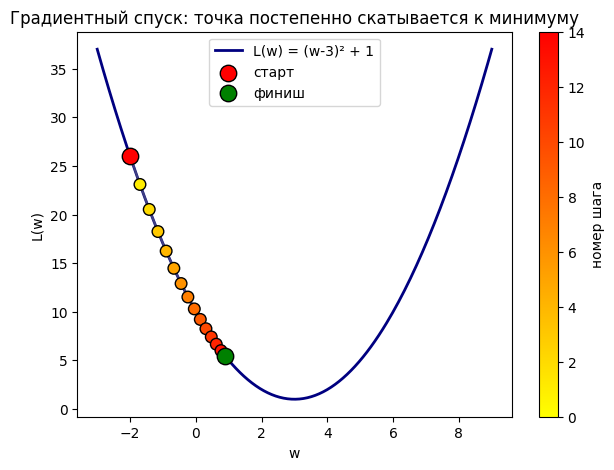

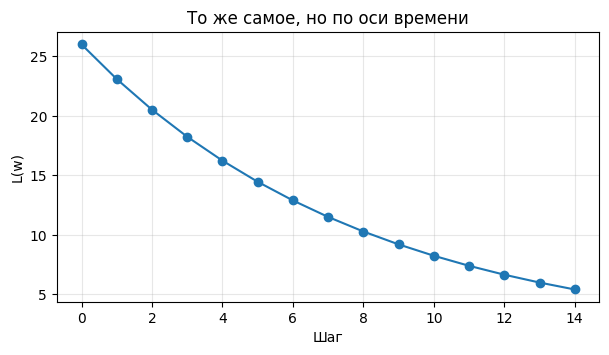

In [19]:
ws_plot = np.linspace(-3, 9, 200)
Ls_plot = [loss_1d(torch.tensor(wv)).item() for wv in ws_plot]

hw = [h[0] for h in history_1d]
hl = [h[1] for h in history_1d]

plt.figure(figsize=(7, 5))
plt.plot(ws_plot, Ls_plot, color="navy", linewidth=2, label="L(w) = (w-3)² + 1", zorder=1)
plt.plot(hw, hl, "-", color="gray", alpha=0.5, zorder=2)
sc = plt.scatter(hw, hl, c=range(len(hw)), cmap="autumn_r", s=70, zorder=3, edgecolor="k")
plt.scatter([hw[0]], [hl[0]], color="red", s=140, zorder=4, label="старт", edgecolor="k")
plt.scatter([hw[-1]], [hl[-1]], color="green", s=140, zorder=4, label="финиш", edgecolor="k")
plt.colorbar(sc, label="номер шага")
plt.xlabel("w")
plt.ylabel("L(w)")
plt.title("Градиентный спуск: точка постепенно скатывается к минимуму")
plt.legend()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(range(len(hl)), hl, marker="o", color="tab:blue")
plt.xlabel("Шаг")
plt.ylabel("L(w)")
plt.title("То же самое, но по оси времени")
plt.grid(alpha=0.3)
plt.show()

> 🎓 **Попробуйте сами:** поставьте `lr = 1.05` и переобучите — что произойдёт с точкой на параболе? А если `lr = 0.01`? Это ровно то же самое «слишком быстро / слишком медленно» с лекции, только теперь видно буквально на графике, как шарик либо скачет, либо еле ползёт.

---

## Часть 3. Вектор признаков «кошка / собака» — быстрый повтор

Как и на лекции: превращаем животных в числа — два признака, размер и пушистость.

X: torch.Size([80, 2]) torch.float32
y: torch.Size([80]) torch.float32


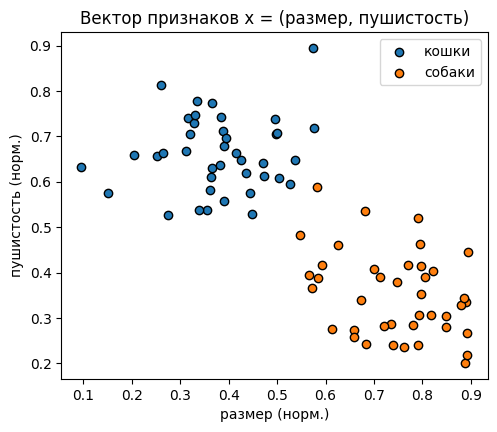

In [9]:
def make_cats_dogs(n_per_class=40, noise=0.10):
    # 0 = кошка, 1 = собака
    cats = np.stack([
        np.random.normal(0.35, noise, n_per_class),  # размер
        np.random.normal(0.70, noise, n_per_class),  # пушистость
    ], axis=1)
    dogs = np.stack([
        np.random.normal(0.70, noise, n_per_class),
        np.random.normal(0.35, noise, n_per_class),
    ], axis=1)
    X = np.vstack([cats, dogs])
    y = np.array([0] * n_per_class + [1] * n_per_class)
    idx = np.random.permutation(len(y))
    return X[idx], y[idx]


X_np, y_np = make_cats_dogs()

# Переводим numpy -> torch. Это то, с чем вы будете работать весь курс.
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32)

print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="кошки", edgecolor="k")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="собаки", edgecolor="k")
plt.xlabel("размер (норм.)")
plt.ylabel("пушистость (норм.)")
plt.legend()
plt.title("Вектор признаков x = (размер, пушистость)")
plt.show()

---

## Часть 4. От перцептрона к гладкому нейрону

На лекции мы установили: ступенчатая активация перцептрона не дифференцируема — градиентный спуск с ней не работает. Поэтому сегодня наш нейрон устроен чуть иначе:

$$z = w \cdot x + b, \qquad \hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$$

Выход — не жёсткий 0 или 1, а число от 0 до 1: «вероятность, что это собака». А в качестве функции потерь возьмём стандартную для классификации — **binary cross-entropy** (бинарную кросс-энтропию): она сильно штрафует уверенные, но неправильные ответы. Формулу дифференцировать руками не нужно — за нас это сделает `loss.backward()`; в PyTorch она уже реализована как `F.binary_cross_entropy`.

In [10]:
def neuron_forward(X, w, b):
    z = X @ w + b            # то самое w*x + b, только сразу для всех примеров матрицей
    return torch.sigmoid(z)  # гладкая активация вместо ступеньки


# быстрая проверка на необученных весах
w_demo = torch.zeros(2, requires_grad=True)
b_demo = torch.zeros(1, requires_grad=True)
pred_demo = neuron_forward(X, w_demo, b_demo)
loss_demo = F.binary_cross_entropy(pred_demo, y)
print("Предсказания необученного нейрона (первые 5):", pred_demo[:5].detach().numpy().round(3))
print("Loss необученного нейрона:", loss_demo.item())

Предсказания необученного нейрона (первые 5): [0.5 0.5 0.5 0.5 0.5]
Loss необученного нейрона: 0.6931472420692444


---

## Часть 5. Обучаем нейрон градиентным спуском — снова вручную

Структура цикла ровно та же, что и на параболе в части 2: посчитать loss → `backward()` → вручную обновить веса → обнулить градиенты. Разница только в том, что теперь у нас не один параметр, а вектор весов `w` (2 числа) и смещение `b`.

In [11]:
w = torch.zeros(2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 2.0
epochs = 300
loss_history = []

for epoch in range(epochs):
    pred = neuron_forward(X, w, b)
    loss = F.binary_cross_entropy(pred, y)

    loss.backward()
    with torch.no_grad():
        # ЗАДАНИЕ: обновите w и b по правилу w <- w - lr*w.grad, b <- b - lr*b.grad
        pass  # ВАШ КОД ЗДЕСЬ (2 строки)
    w.grad.zero_()
    b.grad.zero_()

    loss_history.append(loss.item())
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Эпоха {epoch+1:3d}: loss = {loss.item():.4f}")

Эпоха   1: loss = 0.6931
Эпоха  51: loss = 0.6931
Эпоха 101: loss = 0.6931
Эпоха 151: loss = 0.6931
Эпоха 201: loss = 0.6931
Эпоха 251: loss = 0.6931
Эпоха 300: loss = 0.6931


### Решение

In [12]:
w = torch.zeros(2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 2.0
epochs = 300
loss_history = []

for epoch in range(epochs):
    pred = neuron_forward(X, w, b)
    loss = F.binary_cross_entropy(pred, y)

    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()

    loss_history.append(loss.item())
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"Эпоха {epoch+1:3d}: loss = {loss.item():.4f}")

print("\nФинальные веса: w =", w.detach().numpy().round(3), " b =", round(b.item(), 3))

Эпоха   1: loss = 0.6931
Эпоха  51: loss = 0.2258
Эпоха 101: loss = 0.1494
Эпоха 151: loss = 0.1178
Эпоха 201: loss = 0.1000
Эпоха 251: loss = 0.0883
Эпоха 300: loss = 0.0802

Финальные веса: w = [10.336 -9.876]  b = -0.558


---

## Часть 6. Визуализация: как падает loss и как выглядит граница

Сначала — как убывает loss (это и есть тот самый «шарик, скатывающийся вниз», только теперь в пространстве тысяч возможных весов сразу, а не на одной параболе). Потом — граница решения: обратите внимание, она уже не резкая линия «либо класс 0, либо класс 1», а плавный градиент вероятности — прямое следствие того, что активация гладкая.

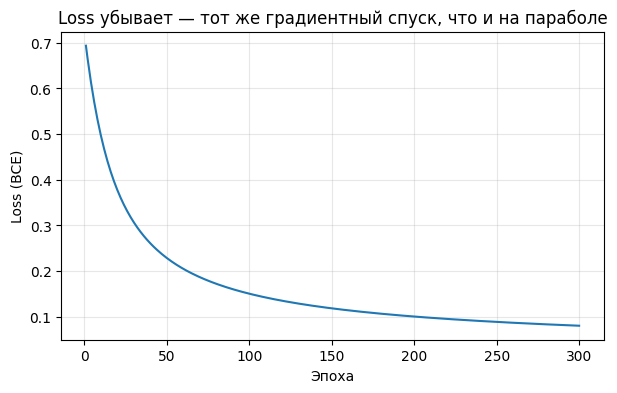

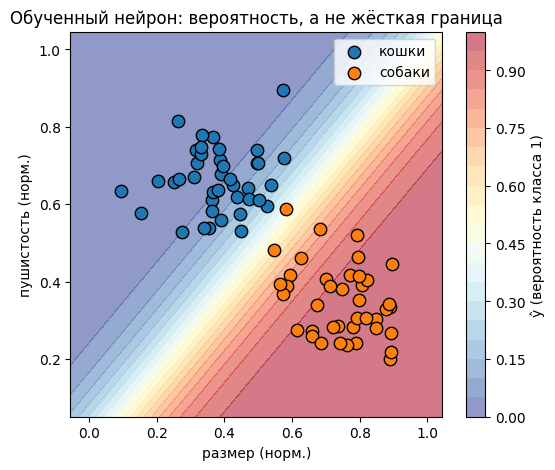

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, color="tab:blue")
plt.xlabel("Эпоха")
plt.ylabel("Loss (BCE)")
plt.title("Loss убывает — тот же градиентный спуск, что и на параболе")
plt.grid(alpha=0.3)
plt.show()


def plot_boundary(forward_fn, X, y, title, label0="кошки", label1="собаки",
                   xlabel="размер (норм.)", ylabel="пушистость (норм.)", cbar_label="ŷ (вероятность класса 1)"):
    plt.figure(figsize=(6, 5))
    x_min, x_max = X[:, 0].min().item() - 0.15, X[:, 0].max().item() + 0.15
    y_min, y_max = X[:, 1].min().item() - 0.15, X[:, 1].max().item() + 0.15
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        preds = forward_fn(grid).numpy().reshape(xx.shape)
    cs = plt.contourf(xx, yy, preds, levels=20, cmap="RdYlBu_r", alpha=0.55)
    plt.colorbar(cs, label=cbar_label)

    Xn, yn = X.numpy(), y.numpy()
    plt.scatter(Xn[yn == 0, 0], Xn[yn == 0, 1], label=label0, edgecolor="k", s=80)
    plt.scatter(Xn[yn == 1, 0], Xn[yn == 1, 1], label=label1, edgecolor="k", s=80)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


plot_boundary(lambda Xg: neuron_forward(Xg, w, b), X, y, "Обученный нейрон: вероятность, а не жёсткая граница")

> 🎓 **Обсуждение:** сравните эту картинку с границей перцептрона из прошлого семинара. Перцептрон давал резкий обрыв между «точно 0» и «точно 1». Здесь — плавный переход: чем дальше от границы, тем увереннее модель. Это прямое следствие гладкости сигмоиды, о которой говорили на лекции.

---

## Часть 7. XOR: один нейрон — и снова не получается

Проверим кодом то, что доказали на лекции: ни жёсткий перцептрон, ни гладкий нейрон с одним слоем не решают XOR — дело не в жёсткости активации, а в самой линейности границы.

Loss в начале: 0.6931   Loss в конце: 0.6931   (ln 2 = 0.6931)
Предсказания: [0.5 0.5 0.5 0.5]  (нужно: [0,1,1,0])


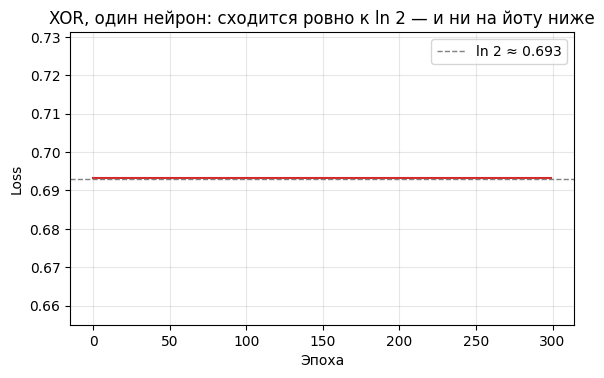

In [14]:
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y_xor = torch.tensor([0., 1., 1., 0.])

w_x = torch.zeros(2, requires_grad=True)
b_x = torch.zeros(1, requires_grad=True)
lr = 1.0
epochs = 300
loss_hist_xor1 = []

for epoch in range(epochs):
    pred = neuron_forward(X_xor, w_x, b_x)
    loss = F.binary_cross_entropy(pred, y_xor)
    loss.backward()
    with torch.no_grad():
        w_x -= lr * w_x.grad
        b_x -= lr * b_x.grad
    w_x.grad.zero_()
    b_x.grad.zero_()
    loss_hist_xor1.append(loss.item())

print(f"Loss в начале: {loss_hist_xor1[0]:.4f}   Loss в конце: {loss_hist_xor1[-1]:.4f}   (ln 2 = {torch.log(torch.tensor(2.0)).item():.4f})")
print("Предсказания:", neuron_forward(X_xor, w_x, b_x).detach().numpy().round(3), " (нужно: [0,1,1,0])")

plt.figure(figsize=(6.5, 3.8))
plt.plot(loss_hist_xor1, color="tab:red")
plt.axhline(y=0.6931, color="gray", linestyle="--", linewidth=1, label="ln 2 ≈ 0.693")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("XOR, один нейрон: сходится ровно к ln 2 — и ни на йоту ниже")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Результат ещё более выразительный, чем «застряло где-то повыше нуля»: модель сходится **ровно** к $\ln 2 \approx 0{,}693$, а все предсказания — ровно к 0.5. Она не пытается угадать хотя бы 3 точки из 4 — она сдаётся полностью и одинаково неуверенно отвечает на все четыре примера.

Это не случайность и не неудачная инициализация — это математически доказуемый факт именно для XOR. У любой линейной модели логит $z=w_1x_1+w_2x_2+b$ устроен так, что сумма $z$ по точкам с меткой 1 всегда равна сумме $z$ по точкам с меткой 0 — какие бы $w$ и $b$ мы ни взяли (проверьте сами: $z(0,1)+z(1,0) = z(0,0)+z(1,1) = w_1+w_2+2b$). А раз так, для симметричной по логитам задачи и выпуклой функции потерь лучшая стратегия — не наклонять границу вообще: любой «наклон», который помогает одной паре точек, ровно настолько же вредит противоположной. Один линейный нейрон в буквальном смысле математически не может сделать на XOR ничего лучше, чем развести руками.

---

## Часть 8. XOR: скрытый слой из двух нейронов — получается

Добавим ровно то, о чём говорили на лекции: скрытый слой из двух нейронов. Каждый из них проведёт свою прямую (как `h₁` и `h₂` на слайде «Два перцептрона — две линии»), а выходной нейрон скомбинирует результаты.

In [15]:
torch.manual_seed(0)

# входы(2) -> скрытый слой(2) -> выход(1), всё вручную матрицами
W1 = torch.randn(2, 2, requires_grad=True)
b1 = torch.zeros(2, requires_grad=True)
W2 = torch.randn(2, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)
params = [W1, b1, W2, b2]


def mlp_forward(X):
    h = torch.sigmoid(X @ W1 + b1)   # скрытый слой: 2 нейрона, каждый - своя прямая
    out = torch.sigmoid(h @ W2 + b2)  # выходной нейрон комбинирует их
    return out.squeeze(-1)


lr = 1.0
epochs = 2000
loss_hist_xor2 = []

for epoch in range(epochs):
    pred = mlp_forward(X_xor)
    loss = F.binary_cross_entropy(pred, y_xor)
    loss.backward()
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad
            p.grad.zero_()
    loss_hist_xor2.append(loss.item())
    if epoch % 400 == 0 or epoch == epochs - 1:
        print(f"Эпоха {epoch+1:4d}: loss = {loss.item():.4f}")

print("\nПредсказания:", mlp_forward(X_xor).detach().numpy().round(3), " (нужно: [0,1,1,0])")

Эпоха    1: loss = 0.8834
Эпоха  401: loss = 0.1097
Эпоха  801: loss = 0.0335
Эпоха 1201: loss = 0.0193
Эпоха 1601: loss = 0.0134
Эпоха 2000: loss = 0.0103

Предсказания: [0.009 0.988 0.988 0.008]  (нужно: [0,1,1,0])


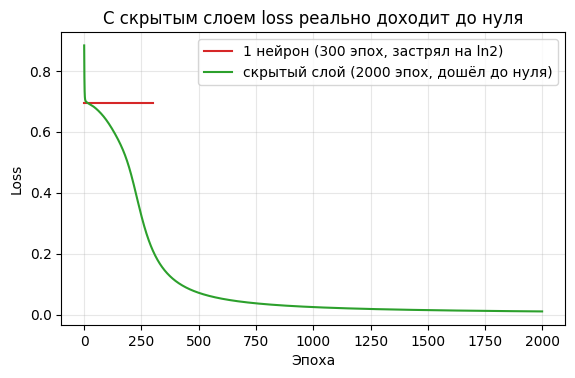

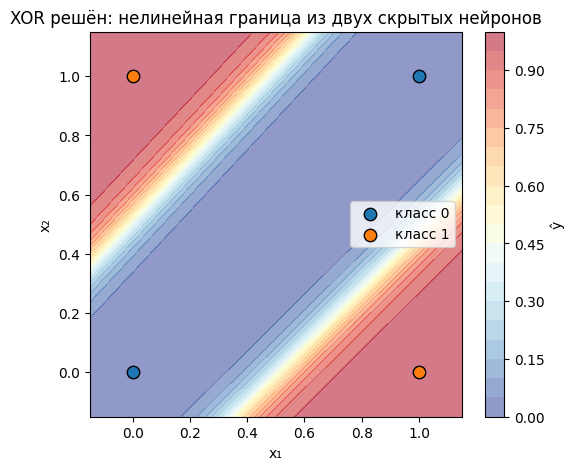

In [16]:
plt.figure(figsize=(6.5, 3.8))
plt.plot(loss_hist_xor1, color="tab:red", label=f"1 нейрон ({len(loss_hist_xor1)} эпох, застрял на ln2)")
plt.plot(loss_hist_xor2, color="tab:green", label=f"скрытый слой ({len(loss_hist_xor2)} эпох, дошёл до нуля)")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("С скрытым слоем loss реально доходит до нуля")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plot_boundary(mlp_forward, X_xor, y_xor, "XOR решён: нелинейная граница из двух скрытых нейронов",
              label0="класс 0", label1="класс 1", xlabel="x\u2081", ylabel="x\u2082", cbar_label="ŷ")

> 🎓 **Обсуждение:** если обучение не сошлось с первого раза — не страшно, это нормально для маленькой сети со случайной инициализацией (та самая чувствительность к начальным весам, о которой ещё пойдёт речь в курсе). Просто перезапустите ячейку с `torch.manual_seed(...)` с другим числом или увеличьте `epochs`.

---

## Итоги семинара

Сегодня мы:
- на игрушечном примере увидели, как PyTorch сам считает производные (`autograd`) — и сверили с формулой руками;
- написали цикл градиентного спуска полностью сами — `backward()` + ручное обновление весов — и увидели, как точка буквально скатывается по параболе к минимуму;
- обучили гладкий нейрон (сигмоида + BCE) на векторах признаков «кошка/собака» — тем же циклом, что и на параболе;
- воспроизвели центральный вывод лекции: один нейрон не решает XOR, а нейрон со скрытым слоем — решает, и увидели обе кривые loss рядом.

**Что дальше:** на лекции 2 — backpropagation разберём формально (что именно происходит внутри `.backward()`), и перейдём на «настоящий» PyTorch — `nn.Module`, `torch.optim`, `DataLoader` — вместо ручных циклов, которые мы писали сегодня.

### Задания на подумать (необязательно, для закрепления дома)
1. Замените `binary_cross_entropy` на `torch.mean((pred - y)**2)` (обычную MSE) — обучение всё ещё работает? Чем отличаются кривые loss?
2. Увеличьте скрытый слой до 4 нейронов вместо 2 — сходится ли обучение быстрее и стабильнее?
3. Постройте `loss.backward()` для функции $L(w_1, w_2) = (w_1-1)^2 + (w_2-2)^2$ и сравните `w1.grad, w2.grad` с аналитическими производными — это ровно та же идея, что на лекционном слайде «Градиент — это вектор».